# 🧠 Brain Tumor MRI Classification

---

### What will we do in this notebook?

1. Download the Brain Tumor MRI dataset
2. Look at the images (EDA)
3. Clean and prepare the data
4. Build a Simple CNN model
5. Build a ResNet50 Transfer Learning model
6. Compare both models
7. Save the model for Streamlit app



## Step 1 — Install and Import Libraries

In [ ]:
# Install kagglehub to download dataset from Kaggle
# The ! means we are running a terminal command inside Colab
!pip install kagglehub -q
print('kagglehub installed!')

✅ kagglehub installed!


In [ ]:
# ── Import all the tools we need ──────────────────────────────────────────────

# numpy → for working with numbers and arrays
import numpy as np

# matplotlib → for drawing graphs and showing images
import matplotlib.pyplot as plt

# os, pathlib, random → for working with files and folders
import os
import random
from pathlib import Path

# PIL → for opening and checking image files
from PIL import Image

# tensorflow → the main deep learning library
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input

# sklearn → for measuring how good our model is
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score, precision_score, recall_score

# ── Make results reproducible (same result every run) ─────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ All libraries imported!')
print('TensorFlow version:', tf.__version__)

✅ All libraries imported!
TensorFlow version: 2.19.0


---
## 📂 Step 2 — Download the Dataset

In [ ]:
import kagglehub

# Download the Brain Tumor MRI dataset from Kaggle
# This may take 1-2 minutes depending on internet speed
print('Downloading dataset... please wait ⏳')
path = kagglehub.dataset_download('masoudnickparvar/brain-tumor-mri-dataset')
print('✅ Dataset downloaded!')
print('Location:', path)

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
✅ Dataset downloaded!
Location: /kaggle/input/brain-tumor-mri-dataset


In [ ]:
# Set up folder paths
BASE_DIR  = Path(path)
TRAIN_DIR = BASE_DIR / 'Training'   # Training images folder
TEST_DIR  = BASE_DIR / 'Testing'    # Testing images folder

# Get the class names (tumor types) from folder names
CLASS_NAMES = sorted([f.name for f in TRAIN_DIR.iterdir() if f.is_dir()])
NUM_CLASSES = len(CLASS_NAMES)

print('✅ Folders found!')
print('Tumor types:', CLASS_NAMES)
print('Number of classes:', NUM_CLASSES)

# Show what folders exist
print('\nFolder structure:')
for folder in TRAIN_DIR.iterdir():
    count = len(list(folder.glob('*.jpg'))) + len(list(folder.glob('*.png')))
    print(f'  Training/{folder.name}: {count} images')

✅ Folders found!
Tumor types: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of classes: 4

Folder structure:
  Training/pituitary: 1400 images
  Training/notumor: 1400 images
  Training/meningioma: 1400 images
  Training/glioma: 1400 images


---
## 📊 Step 3 — EDA (Exploratory Data Analysis)

**EDA means: Let's LOOK at our data before training!**

We will check:
- How many images do we have?
- What do the images look like?
- Are some classes bigger than others?

In [ ]:
# ── Count images in each class ────────────────────────────────────────────────

train_counts = {}  # dictionary to store training image counts
test_counts  = {}  # dictionary to store testing image counts

print('IMAGE COUNT PER CLASS')
print('=' * 40)

for cls in CLASS_NAMES:
    # Count all jpg and png images in each class folder
    train_imgs = list((TRAIN_DIR / cls).glob('*.jpg')) + \
                 list((TRAIN_DIR / cls).glob('*.png'))
    test_imgs  = list((TEST_DIR  / cls).glob('*.jpg')) + \
                 list((TEST_DIR  / cls).glob('*.png'))

    train_counts[cls] = len(train_imgs)
    test_counts[cls]  = len(test_imgs)

    print(f'{cls:<15} | Train: {len(train_imgs):4d} | Test: {len(test_imgs):3d}')

print('=' * 40)
total = sum(train_counts.values()) + sum(test_counts.values())
print(f'Total images in dataset: {total}')

IMAGE COUNT PER CLASS
glioma          | Train: 1400 | Test: 400
meningioma      | Train: 1400 | Test: 400
notumor         | Train: 1400 | Test: 400
pituitary       | Train: 1400 | Test: 400
Total images in dataset: 7200


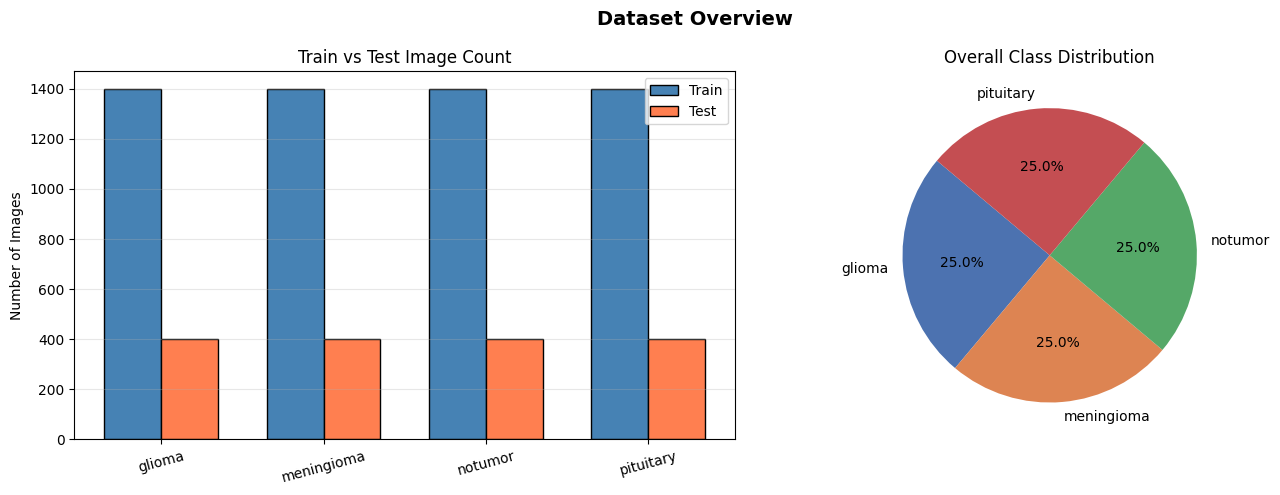

✅ Chart saved!


In [ ]:
# ── Bar chart: How many images per class? ─────────────────────────────────────

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Dataset Overview', fontsize=14, fontweight='bold')

# Left chart: Bar chart comparing Train vs Test per class
x     = range(NUM_CLASSES)
width = 0.35
axes[0].bar([i - width/2 for i in x], train_counts.values(),
            width=width, label='Train', color='steelblue', edgecolor='black')
axes[0].bar([i + width/2 for i in x], test_counts.values(),
            width=width, label='Test',  color='coral',     edgecolor='black')
axes[0].set_xticks(x)
axes[0].set_xticklabels(CLASS_NAMES, rotation=15)
axes[0].set_title('Train vs Test Image Count')
axes[0].set_ylabel('Number of Images')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Right chart: Pie chart showing class proportions
total_per_class = [train_counts[c] + test_counts[c] for c in CLASS_NAMES]
axes[1].pie(total_per_class, labels=CLASS_NAMES, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452','#55A868','#C44E52'], startangle=140)
axes[1].set_title('Overall Class Distribution')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved!')

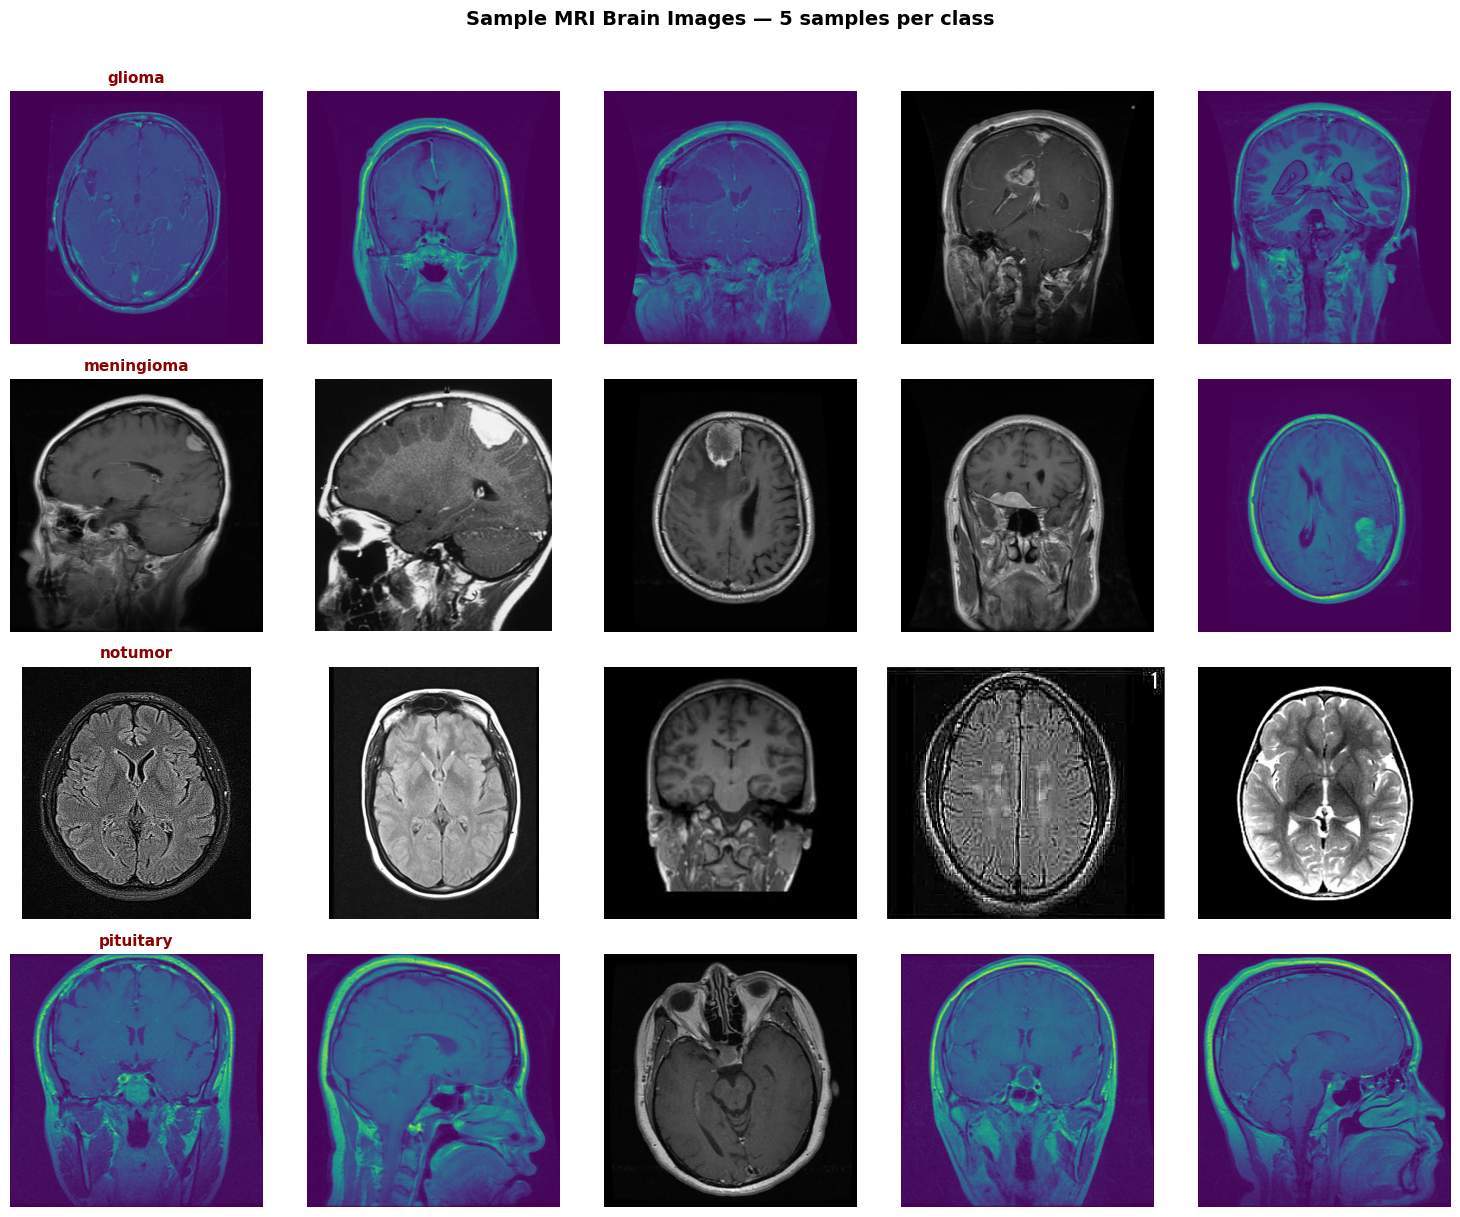

✅ Sample images shown!


In [ ]:
# ── Show sample images from each class ───────────────────────────────────────
# This helps us SEE what brain MRI images look like for each tumor type

fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(15, NUM_CLASSES * 3))
fig.suptitle('Sample MRI Brain Images — 5 samples per class',
             fontsize=14, fontweight='bold', y=1.01)

for row, cls in enumerate(CLASS_NAMES):
    # Get all images for this class
    all_imgs = list((TRAIN_DIR / cls).glob('*.jpg'))
    # Pick 5 random images
    sample = random.sample(all_imgs, min(5, len(all_imgs)))

    for col, img_path in enumerate(sample):
        img = plt.imread(img_path)
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        # Show class label only on the first image of each row
        if col == 0:
            axes[row][col].set_title(cls, fontsize=11,
                                      fontweight='bold', color='darkred')

plt.tight_layout()
plt.savefig('sample_images.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Sample images shown!')

In [ ]:
# ── Check image sizes ────────────────────────────────────────────────────────
# Images may have different sizes — we need to resize them all to the same size

widths  = []
heights = []

for cls in CLASS_NAMES:
    for img_path in list((TRAIN_DIR / cls).glob('*.jpg'))[:50]: # check 50 per class
        with Image.open(img_path) as img:
            w, h = img.size
            widths.append(w)
            heights.append(h)

print('Image Size Analysis:')
print(f'  Width  → Min: {min(widths)}, Max: {max(widths)}, Avg: {int(np.mean(widths))}')
print(f'  Height → Min: {min(heights)}, Max: {max(heights)}, Avg: {int(np.mean(heights))}')
print()
print('👉 We will resize ALL images to 128x128 in the next step')

Image Size Analysis:
  Width  → Min: 150, Max: 680, Avg: 449
  Height → Min: 192, Max: 680, Avg: 451

👉 We will resize ALL images to 128x128 in the next step


---
## 🧹 Step 4 — Data Cleaning

Data cleaning means making sure all our images are **good and usable**.
We check for:
- ❌ Broken/corrupt images that cannot be opened
- 📐 Images that are too small or too large

In [ ]:
# Check for corrupt/broken images
# A corrupt image is one that cannot be opened properly

broken = []  # list to store any broken image paths

print('Checking for broken images...')

for split_dir in [TRAIN_DIR, TEST_DIR]:
    for cls in CLASS_NAMES:
        for img_path in (split_dir / cls).glob('*'):
            try:
                with Image.open(img_path) as img:
                    img.verify()  # verify() checks if image file is valid
            except Exception:
                broken.append(str(img_path))  # if error, add to broken list

# Show results
if len(broken) == 0:
    print('✅ No broken images found! All images are clean.')
else:
    print(f'❌ Found {len(broken)} broken image(s):')
    for b in broken:
        print(' -', b)

Checking for broken images...
✅ No broken images found! All images are clean.


---
## ⚙️ Step 5 — Preprocessing

Preprocessing means **preparing images for the model**.

We do 3 things:
1. **Resize** → Change all images to same size (128x128)
2. **Normalize** → Change pixel values from 0-255 to 0-1 (easier for model to learn)
3. **Augment** → Create slight variations of training images

**What is Augmentation?**
Imagine having 1000 photos. Augmentation creates MORE photos by:
- Rotating images slightly
- Flipping them left/right
- Zooming in/out

This helps the model learn better without needing more real images!

In [ ]:
# ── Settings ──────────────────────────────────────────────────────────────────
IMG_SIZE   = (128, 128)  # Resize all images to 128x128 pixels
BATCH_SIZE = 32          # Process 32 images at a time

# ── Training Data Generator ───────────────────────────────────────────────────
# This generator will:
#   - Load images from the Training folder
#   - Resize them to 128x128
#   - Normalize pixel values (divide by 255)
#   - Apply random augmentations
#   - Split 20% for validation automatically

train_datagen = ImageDataGenerator(
    rescale            = 1.0/255,  # Normalize: pixel 0-255 becomes 0.0-1.0
    rotation_range     = 15,       # Rotate image up to 15 degrees randomly
    zoom_range         = 0.1,      # Zoom in or out up to 10%
    horizontal_flip    = True,     # Randomly flip image left/right
    width_shift_range  = 0.1,      # Shift image left/right up to 10%
    height_shift_range = 0.1,      # Shift image up/down up to 10%
    validation_split   = 0.2       # Use 20% of training data for validation
)

# Test data generator: ONLY normalize, NO augmentation
# We never augment test data — we want to test on real images!
test_datagen = ImageDataGenerator(rescale=1.0/255)

# ── Create the data loaders ───────────────────────────────────────────────────

# Training set (80% of Training folder)
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size  = IMG_SIZE,       # Resize every image to 128x128
    batch_size   = BATCH_SIZE,     # Load 32 images at once
    class_mode   = 'categorical',  # 4 classes → we need one-hot encoding
    subset       = 'training',     # This is the training portion
    seed         = SEED
)

# Validation set (20% of Training folder)
val_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    subset      = 'validation',    # This is the validation portion
    seed        = SEED
)

# Test set (Testing folder — completely unseen data)
test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size = IMG_SIZE,
    batch_size  = BATCH_SIZE,
    class_mode  = 'categorical',
    shuffle     = False            # Don't shuffle — important for evaluation!
)

print('\n✅ Data generators ready!')
print('Class mapping:', train_generator.class_indices)

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.

✅ Data generators ready!
Class mapping: {'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}


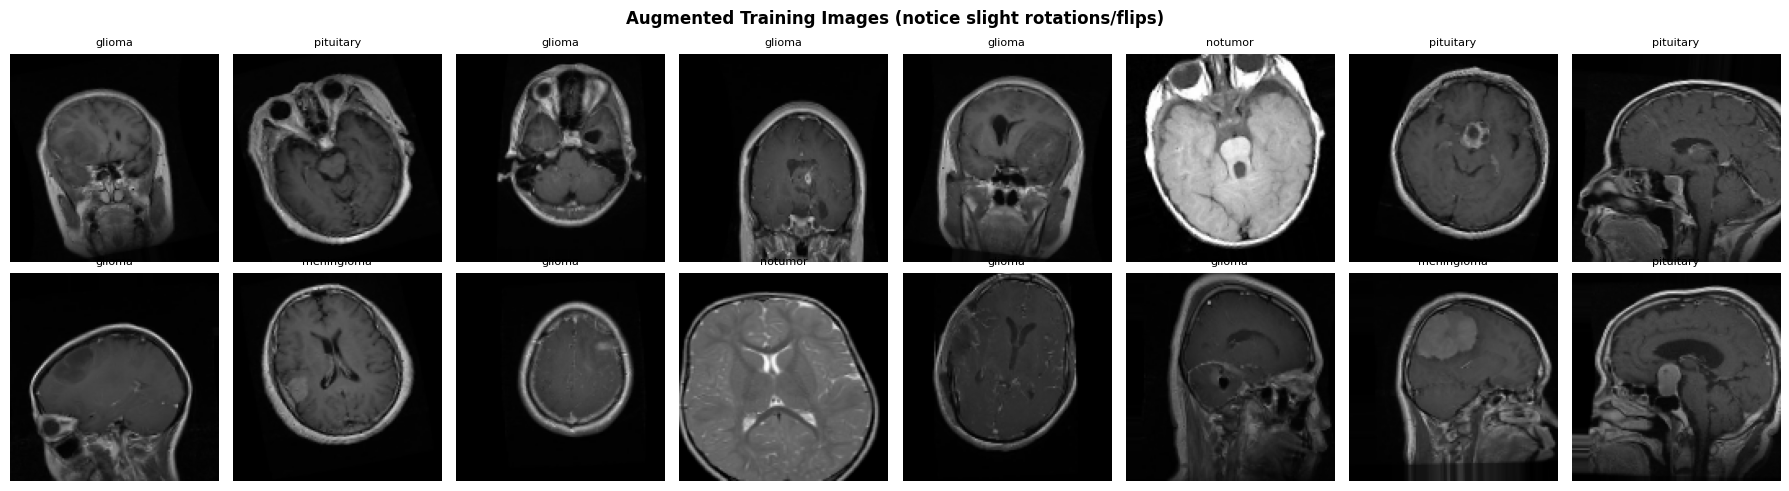

✅ Augmented samples shown!


In [ ]:
# ── Visualise augmented images ────────────────────────────────────────────────
# Let's see what augmented images look like

images, labels = next(train_generator)  # Get one batch of images

# Reverse class mapping: number → class name
idx_to_class = {v: k for k, v in train_generator.class_indices.items()}

fig, axes = plt.subplots(2, 8, figsize=(18, 5))
fig.suptitle('Augmented Training Images (notice slight rotations/flips)',
             fontsize=12, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        ax.set_title(idx_to_class[np.argmax(labels[i])], fontsize=8)
    ax.axis('off')

plt.tight_layout()
plt.savefig('augmented_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Augmented samples shown!')

---
## 🏗️ Step 6 — Build Model 1: Simple CNN

### How does a CNN work?

Think of it like a human looking at an image:
- First you notice **edges and lines**
- Then you see **shapes** (circles, curves)
- Finally you recognise **objects** (tumor shape)

CNN does the exact same thing layer by layer!

**Key layers:**
- `Conv2D` → Finds patterns (edges, shapes) using small filters
- `MaxPooling2D` → Makes image smaller, keeps important info
- `Dropout` → Randomly turns off neurons to prevent memorizing
- `Dense` → Makes the final decision

In [ ]:
# Build a Simple CNN model
# Sequential = layers stacked one after another (like floors in a building)

cnn_model = models.Sequential(name='Simple_CNN')

# ── BLOCK 1: Find basic patterns (edges, lines) ───────────────────────────────
# 32 filters, each 3x3 pixels, relu activation removes negative values
cnn_model.add(layers.Conv2D(32, (3,3), activation='relu',
                             padding='same',
                             input_shape=(128, 128, 3)))  # 3 = RGB channels
# MaxPooling reduces image from 128x128 to 64x64
cnn_model.add(layers.MaxPooling2D(2, 2))

# ── BLOCK 2: Find medium patterns (curves, shapes) ───────────────────────────
# 64 filters now — more complex patterns
cnn_model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
# MaxPooling reduces image from 64x64 to 32x32
cnn_model.add(layers.MaxPooling2D(2, 2))

# ── BLOCK 3: Find complex patterns (tumor shapes) ────────────────────────────
# 128 filters — very complex patterns
cnn_model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
# MaxPooling reduces image from 32x32 to 16x16
cnn_model.add(layers.MaxPooling2D(2, 2))

# ── CLASSIFIER: Make the final decision ──────────────────────────────────────
# Flatten: Convert 3D output (16x16x128) into 1D list of numbers
cnn_model.add(layers.Flatten())

# Dropout: Randomly turn OFF 50% of neurons during training
# This prevents the model from memorizing the training data (overfitting)
cnn_model.add(layers.Dropout(0.5))

# Dense layer: 128 neurons to combine all patterns learned
cnn_model.add(layers.Dense(128, activation='relu'))
cnn_model.add(layers.Dropout(0.3))

# Output layer: 4 neurons (one per tumor type)
# softmax gives probability for each class (all 4 probabilities add up to 1.0)
cnn_model.add(layers.Dense(NUM_CLASSES, activation='softmax'))

# Show model summary
cnn_model.summary()
print('\n✅ Simple CNN model built!')

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Simple_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,196 (16.36 MB)

 Trainable params: 4,288,196 (16.36 MB)

 Non-trainable params: 0 (0.00 B)


✅ Simple CNN model built!


In [ ]:
# ── Compile the model ─────────────────────────────────────────────────────────
# Before training, we need to tell the model:
#   optimizer → how to update weights (Adam is the most popular)
#   loss      → how to measure mistakes (categorical_crossentropy for 4 classes)
#   metrics   → what to show us during training (accuracy)

cnn_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# ── Callbacks ─────────────────────────────────────────────────────────────────
# Callbacks are helpers that run automatically during training

# EarlyStopping: Stop training if accuracy stops improving for 5 epochs
# This saves time and prevents overfitting
early_stop = EarlyStopping(
    monitor              = 'val_accuracy', # Watch validation accuracy
    patience             = 5,              # Stop after 5 epochs of no improvement
    restore_best_weights = True,           # Go back to the best weights found
    verbose              = 1
)

# ReduceLROnPlateau: Reduce learning rate if model stops improving
# Think of learning rate as the step size — smaller steps = more precise
reduce_lr = ReduceLROnPlateau(
    monitor  = 'val_loss',
    factor   = 0.5,          # Reduce learning rate by half
    patience = 3,
    verbose  = 1
)

# ModelCheckpoint: Automatically save the best model during training
save_best_cnn = ModelCheckpoint(
    'best_cnn_model.keras',    # Save as .keras format (newer format)
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 0
)

print('✅ Model compiled and callbacks ready!')

✅ Model compiled and callbacks ready!


In [ ]:
# ── Train the Simple CNN ──────────────────────────────────────────────────────
# epochs = how many times the model sees ALL training images
# One epoch = model sees every training image once

print('🚀 Starting CNN training...')
print('This will take about 5-10 minutes with GPU\n')

history_cnn = cnn_model.fit(
    train_generator,             # Training images
    epochs          = 25,        # Train for up to 25 rounds
    validation_data = val_generator,  # Check performance on validation images
    callbacks       = [early_stop, reduce_lr, save_best_cnn],
    verbose         = 1
)

print('\n✅ CNN training complete!')

🚀 Starting CNN training...
This will take about 5-10 minutes with GPU

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 42s 256ms/step - accuracy: 0.5527 - loss: 1.0070 - val_accuracy: 0.6786 - val_loss: 0.7983 - learning_rate: 0.0010
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 235ms/step - accuracy: 0.7174 - loss: 0.6953 - val_accuracy: 0.7455 - val_loss: 0.6235 - learning_rate: 0.0010
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 32s 229ms/step - accuracy: 0.7540 - loss: 0.6196 - val_accuracy: 0.7634 - val_loss: 0.5825 - learning_rate: 0.0010
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 237ms/step - accuracy: 0.7650 - loss: 0.5899 - val_accuracy: 0.7714 - val_loss: 0.5506 - learning_rate: 0.0010
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 238ms/step - accuracy: 0.7931 - loss: 0.5346 - val_accuracy: 0.7786 - val_loss: 0.5121 - learning_rate: 0.0010
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 33s 236ms/step - accuracy: 0.8009 - loss: 0.5164 - val_accuracy: 0.8116 - val_loss: 0.4726 - learning_rate: 0.0010

---
## 🔁 Step 7 — Build Model 2: ResNet50 Transfer Learning

### What is Transfer Learning? 🚗

Imagine you already know how to drive a **car**.
Now you need to learn to drive a **truck**.
You don't start from zero — you use your existing car-driving knowledge!

**Transfer Learning works the same way:**
- ResNet50 was already trained on **1.2 million images** (cats, dogs, cars, etc.)
- It already learned to detect edges, shapes, textures
- We just teach it the **last step** — recognizing tumor types
- Result: **Better accuracy with less training time!**

In [ ]:
# ResNet50 needs its own special preprocessing
# (different from our simple /255 normalization)
# So we create NEW data generators specifically for ResNet

resnet_train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,  # ResNet's special preprocessing
    rotation_range         = 15,
    zoom_range             = 0.1,
    horizontal_flip        = True,
    width_shift_range      = 0.1,
    height_shift_range     = 0.1,
    validation_split       = 0.2
)
resnet_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

# Create loaders
resnet_train_gen = resnet_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='training', seed=SEED
)
resnet_val_gen = resnet_train_datagen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', subset='validation', seed=SEED
)
resnet_test_gen = resnet_test_datagen.flow_from_directory(
    TEST_DIR, target_size=IMG_SIZE, batch_size=BATCH_SIZE,
    class_mode='categorical', shuffle=False
)

print('✅ ResNet50 data generators ready!')

Found 4480 images belonging to 4 classes.
Found 1120 images belonging to 4 classes.
Found 1600 images belonging to 4 classes.
✅ ResNet50 data generators ready!


In [ ]:
# ── Load pre-trained ResNet50 ─────────────────────────────────────────────────
# weights='imagenet' → use weights already trained on 1.2 million images
# include_top=False  → remove the last layer (we will add our own 4-class layer)

base_model = ResNet50(
    weights     = 'imagenet',     # Pre-trained weights from ImageNet
    include_top = False,          # Remove original output layer
    input_shape = (128, 128, 3)   # Our image size
)

# FREEZE the base model
# Frozen = we will NOT change these weights
# We want to keep the knowledge ResNet already has!
base_model.trainable = False

print(f'✅ ResNet50 loaded! Total layers: {len(base_model.layers)}')
print('Base model is FROZEN — we will only train our new layers on top')

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
✅ ResNet50 loaded! Total layers: 175
Base model is FROZEN — we will only train our new layers on top


In [ ]:
# ── Build full ResNet50 model ─────────────────────────────────────────────────
# We add our own layers on TOP of ResNet50

resnet_model = models.Sequential([
    base_model,                          # ResNet50 as feature extractor (frozen)
    layers.GlobalAveragePooling2D(),     # Convert 3D features to 1D
    layers.Dense(256, activation='relu'), # Our custom dense layer
    layers.Dropout(0.4),                 # Prevent overfitting
    layers.Dense(NUM_CLASSES, activation='softmax')  # Final output: 4 classes
], name='ResNet50_Transfer')

resnet_model.summary()
print('\n✅ ResNet50 Transfer Learning model built!')

Model: "ResNet50_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)


✅ ResNet50 Transfer Learning model built!


In [ ]:
# ── Compile and Train ResNet50 ────────────────────────────────────────────────

resnet_model.compile(
    optimizer = 'adam',
    loss      = 'categorical_crossentropy',
    metrics   = ['accuracy']
)

# Callbacks for ResNet
resnet_early_stop = EarlyStopping(
    monitor='val_accuracy', patience=5,
    restore_best_weights=True, verbose=1
)
resnet_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=3, verbose=1
)

# ⚠️ IMPORTANT: Save as .keras format (NOT .h5)
# This is the new format that works without version errors!
save_best_resnet = ModelCheckpoint(
    'best_resnet_model.keras',   # ← .keras format!
    monitor        = 'val_accuracy',
    save_best_only = True,
    verbose        = 0
)

print('🚀 Starting ResNet50 training...')
print('This should be faster than CNN because we only train the top layers!\n')

history_resnet = resnet_model.fit(
    resnet_train_gen,
    epochs          = 50,
    validation_data = resnet_val_gen,
    callbacks       = [resnet_early_stop, resnet_reduce_lr, save_best_resnet],
    verbose         = 1
)

print('\n✅ ResNet50 training complete!')

🚀 Starting ResNet50 training...
This should be faster than CNN because we only train the top layers!

Epoch 1/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 53s 292ms/step - accuracy: 0.7728 - loss: 0.6466 - val_accuracy: 0.8259 - val_loss: 0.4729 - learning_rate: 0.0010
Epoch 2/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 35s 251ms/step - accuracy: 0.8346 - loss: 0.4228 - val_accuracy: 0.8679 - val_loss: 0.3485 - learning_rate: 0.0010
Epoch 3/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 256ms/step - accuracy: 0.8576 - loss: 0.3731 - val_accuracy: 0.8741 - val_loss: 0.3063 - learning_rate: 0.0010
Epoch 4/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 39s 277ms/step - accuracy: 0.8712 - loss: 0.3319 - val_accuracy: 0.8813 - val_loss: 0.3091 - learning_rate: 0.0010
Epoch 5/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 255ms/step - accuracy: 0.8799 - loss: 0.3121 - val_accuracy: 0.8920 - val_loss: 0.2718 - learning_rate: 0.0010
Epoch 6/25
140/140 ━━━━━━━━━━━━━━━━━━━━ 36s 257ms/step - accuracy: 0.8866 - loss: 0.2903 - val_accuracy: 0.8946 - val_loss:

---
## 📈 Step 8 — Plot Training Graphs

We plot **accuracy** and **loss** curves to understand how training went.

**Good training looks like:**
- Train accuracy goes UP over time ✅
- Validation accuracy also goes UP ✅
- Both lines are close together ✅

**Bad training (overfitting) looks like:**
- Train accuracy = very high (e.g. 99%) ❌
- Validation accuracy = much lower (e.g. 60%) ❌

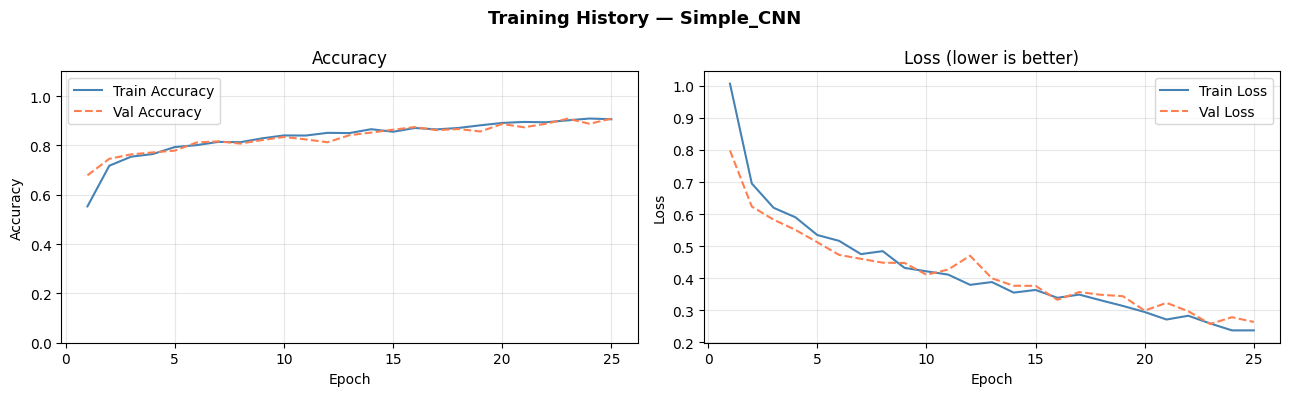

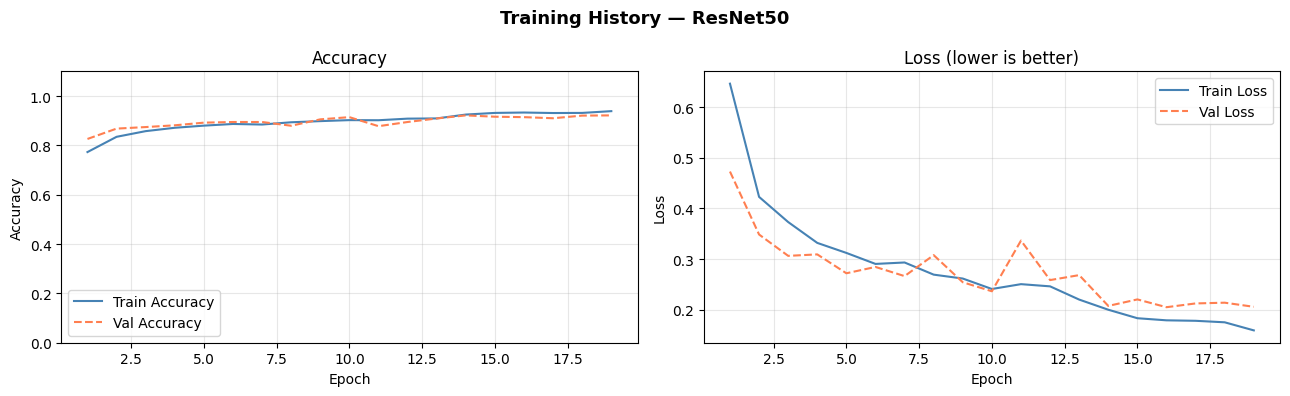

In [ ]:
def plot_training_curves(history, model_name):
    """Plot accuracy and loss curves for training and validation."""

    # Get values from history
    acc      = history.history['accuracy']
    val_acc  = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs   = range(1, len(acc) + 1)  # epoch numbers: 1, 2, 3...

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(f'Training History — {model_name}',
                 fontsize=13, fontweight='bold')

    # ── Accuracy graph ────────────────────────────────────────────────────────
    ax1.plot(epochs, acc,     color='steelblue', label='Train Accuracy')
    ax1.plot(epochs, val_acc, color='coral',     label='Val Accuracy', linestyle='--')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(alpha=0.3)
    ax1.set_ylim(0, 1.1)

    # ── Loss graph ────────────────────────────────────────────────────────────
    ax2.plot(epochs, loss,     color='steelblue', label='Train Loss')
    ax2.plot(epochs, val_loss, color='coral',     label='Val Loss', linestyle='--')
    ax2.set_title('Loss (lower is better)')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(f'{model_name}_history.png', dpi=150, bbox_inches='tight')
    plt.show()


# Plot for both models
plot_training_curves(history_cnn,    'Simple_CNN')
plot_training_curves(history_resnet, 'ResNet50')

---
## 🎯 Step 9 — Evaluate Models on Test Data

Now we test how well the models work on **completely new, unseen images** (the test set).

**Metrics explained simply:**
- **Accuracy** → Out of 100 images, how many did we get right?
- **Precision** → When model says "Glioma", how often is it actually Glioma?
- **Recall** → Out of all real Glioma cases, how many did we catch?
- **F1-Score** → Balance between Precision and Recall (best single metric)

In [ ]:
def evaluate_model(model, test_gen, model_name):
    """Evaluate model and print all metrics."""

    sep = '=' * 50
    print(f'\n{sep}')
    print(f'  Results: {model_name}')
    print(sep)

    # Reset generator to start from beginning
    test_gen.reset()

    # Get predictions
    # predict() returns probability for each of the 4 classes
    # Example output: [0.05, 0.80, 0.10, 0.05]
    # This means: 5% Glioma, 80% Meningioma, 10% No Tumor, 5% Pituitary
    y_pred_prob = model.predict(test_gen, verbose=0)

    # argmax picks the class with the HIGHEST probability
    # In above example: argmax = 1 (Meningioma)
    y_pred = np.argmax(y_pred_prob, axis=1)

    # True labels (the correct answers)
    y_true = test_gen.classes

    # Calculate loss and accuracy
    loss, acc = model.evaluate(test_gen, verbose=0)
    print(f'\nTest Loss     : {loss:.4f}')
    print(f'Test Accuracy : {acc * 100:.2f}%')

    # Detailed report
    print('\nDetailed Report (per class):')
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

    return y_true, y_pred, y_pred_prob, acc


# Evaluate Simple CNN
y_true_cnn, y_pred_cnn, y_prob_cnn, acc_cnn = evaluate_model(
    cnn_model, test_generator, 'Simple CNN'
)

# Evaluate ResNet50
y_true_res, y_pred_res, y_prob_res, acc_res = evaluate_model(
    resnet_model, resnet_test_gen, 'ResNet50'
)


  Results: Simple CNN

Test Loss     : 1.0943
Test Accuracy : 82.19%

Detailed Report (per class):
              precision    recall  f1-score   support

      glioma       0.96      0.61      0.74       400
  meningioma       0.77      0.70      0.73       400
     notumor       0.73      1.00      0.84       400
   pituitary       0.91      0.98      0.95       400

    accuracy                           0.82      1600
   macro avg       0.84      0.82      0.82      1600
weighted avg       0.84      0.82      0.82      1600


  Results: ResNet50

Test Loss     : 0.4918
Test Accuracy : 86.62%

Detailed Report (per class):
              precision    recall  f1-score   support

      glioma       0.91      0.71      0.80       400
  meningioma       0.81      0.79      0.80       400
     notumor       0.87      1.00      0.93       400
   pituitary       0.88      0.97      0.92       400

    accuracy                           0.87      1600
   macro avg       0.87      0.87      0.

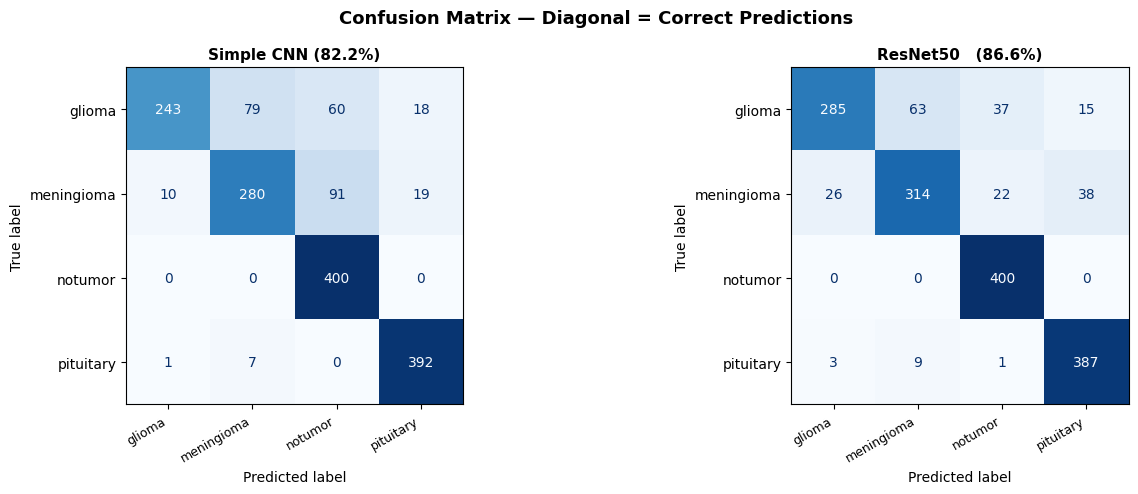

✅ Confusion matrices plotted!


In [ ]:
# ── Confusion Matrix ──────────────────────────────────────────────────────────
# A confusion matrix is a table showing:
#   - ROWS = Actual class (ground truth)
#   - COLUMNS = Predicted class
#   - Numbers on DIAGONAL = Correct predictions (we want these HIGH)
#   - Numbers off diagonal = Wrong predictions (we want these LOW)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Confusion Matrix — Diagonal = Correct Predictions',
             fontsize=13, fontweight='bold')

for ax, y_true, y_pred, title in [
    (axes[0], y_true_cnn, y_pred_cnn, f'Simple CNN ({acc_cnn*100:.1f}%)'),
    (axes[1], y_true_res, y_pred_res, f'ResNet50   ({acc_res*100:.1f}%)')
]:
    cm   = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xticklabels(CLASS_NAMES, rotation=30, ha='right', fontsize=9)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Confusion matrices plotted!')

---
## ⚖️ Step 10 — Compare Both Models

In [ ]:
# Calculate all metrics for both models

def get_metrics(y_true, y_pred):
    """Calculate Accuracy, Precision, Recall, F1 for a model."""
    return {
        'Accuracy'  : round(np.mean(y_true == y_pred) * 100, 2),
        'Precision' : round(precision_score(y_true, y_pred, average='weighted') * 100, 2),
        'Recall'    : round(recall_score   (y_true, y_pred, average='weighted') * 100, 2),
        'F1-Score'  : round(f1_score       (y_true, y_pred, average='weighted') * 100, 2)
    }

cnn_metrics    = get_metrics(y_true_cnn, y_pred_cnn)
resnet_metrics = get_metrics(y_true_res, y_pred_res)

# Print comparison table
print('\n' + '='*52)
print(f'{"Metric":<15} {"Simple CNN":>12} {"ResNet50":>12}')
print('='*52)
for metric in cnn_metrics:
    c = cnn_metrics[metric]
    r = resnet_metrics[metric]
    better = '  ← Better ✅' if r > c else ''
    print(f'{metric:<15} {c:>11}% {r:>11}% {better}')
print('='*52)


Metric            Simple CNN     ResNet50
Accuracy              82.19%       86.62%   ← Better ✅
Precision             84.04%       86.76%   ← Better ✅
Recall                82.19%       86.62%   ← Better ✅
F1-Score              81.53%       86.22%   ← Better ✅


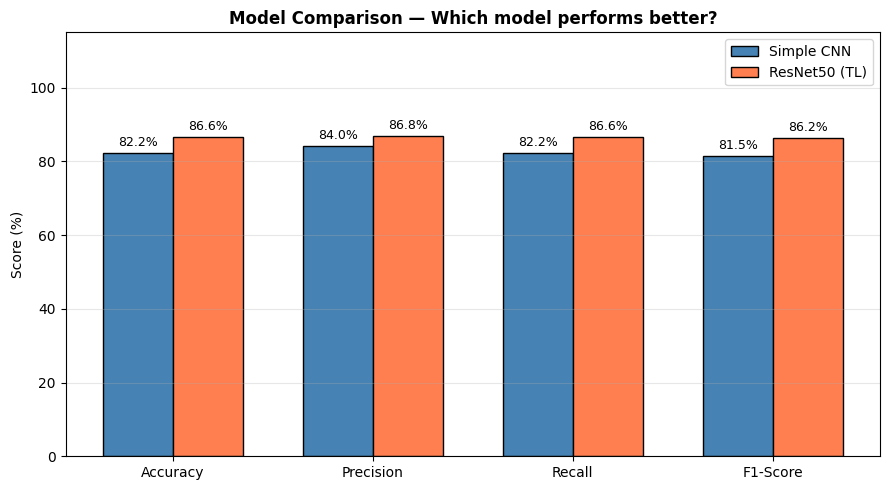

✅ Comparison chart saved!


In [ ]:
# Visual bar chart comparison

metrics  = list(cnn_metrics.keys())
cnn_vals = list(cnn_metrics.values())
res_vals = list(resnet_metrics.values())

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(x - width/2, cnn_vals, width, label='Simple CNN',
               color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, res_vals, width, label='ResNet50 (TL)',
               color='coral',     edgecolor='black')

ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)')
ax.set_title('Model Comparison — Which model performs better?',
             fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.bar_label(bars1, fmt='%.1f%%', padding=3, fontsize=9)
ax.bar_label(bars2, fmt='%.1f%%', padding=3, fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Comparison chart saved!')

---
## 🔍 Step 11 — See Predictions Visually
🟢 Green title = Model predicted CORRECTLY
🔴 Red title = Model predicted WRONGLY

/tmp/ipykernel_1331/112133962.py:23: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1331/112133962.py:23: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1331/112133962.py:24: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'predictions_{model_name}.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_1331/112133962.py:24: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig(f'predictions_{model_name}.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) 

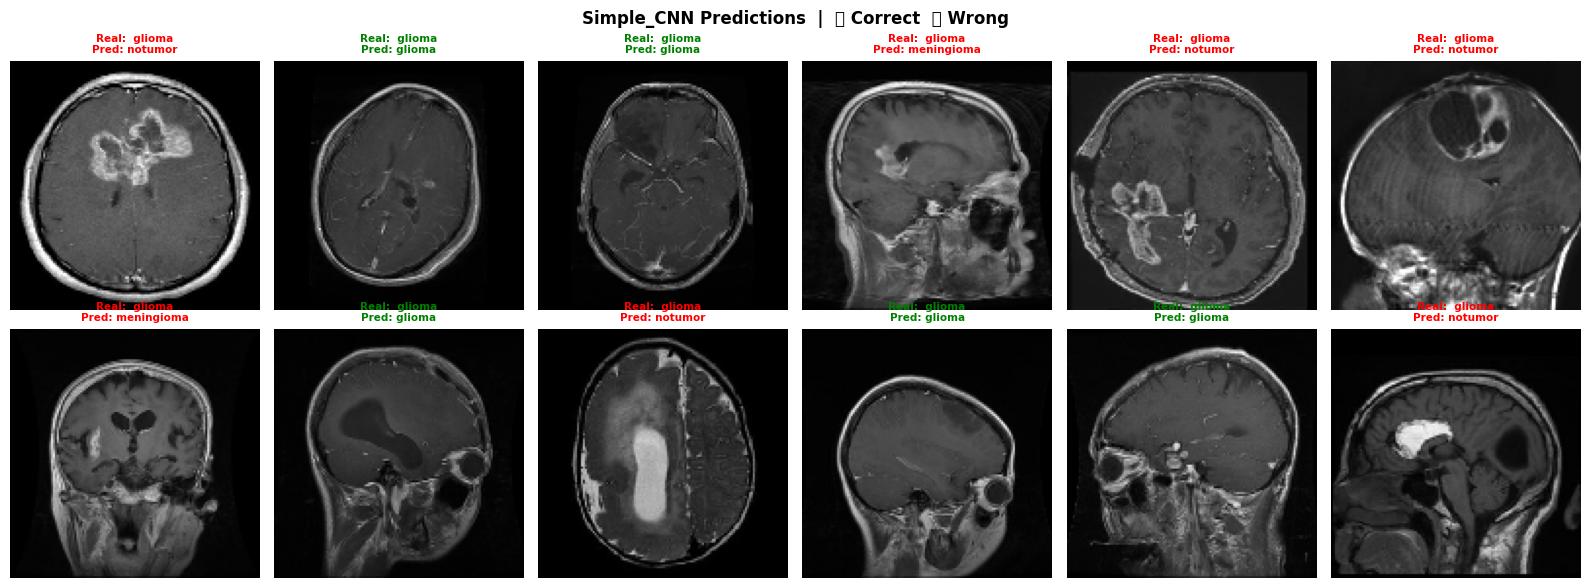

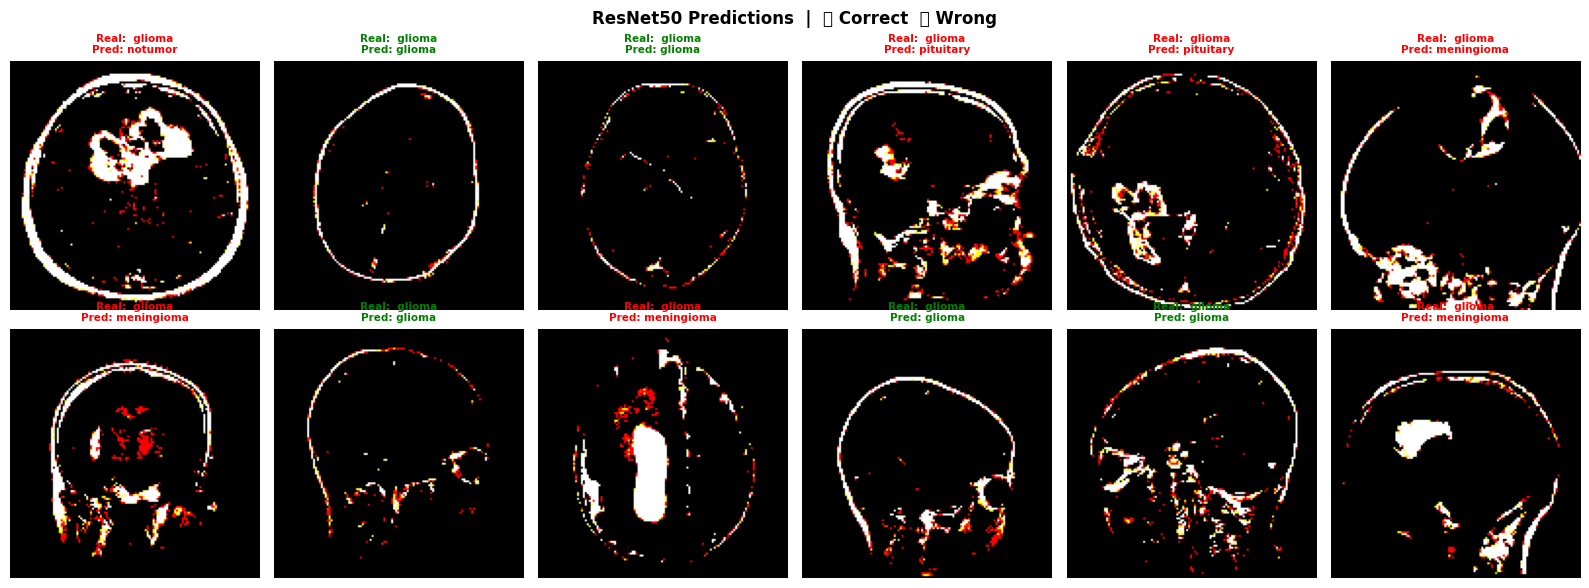

In [ ]:
def show_predictions(y_true, y_pred, generator, model_name):
    """Show 12 sample predictions with colour coding."""

    generator.reset()
    images, _ = next(generator)  # Get one batch of images

    fig, axes = plt.subplots(2, 6, figsize=(16, 6))
    fig.suptitle(f'{model_name} Predictions  |  🟢 Correct  🔴 Wrong',
                 fontsize=12, fontweight='bold')

    for i, ax in enumerate(axes.flat):
        if i >= len(images):
            break
        true_label = CLASS_NAMES[y_true[i]]
        pred_label = CLASS_NAMES[y_pred[i]]
        color = 'green' if true_label == pred_label else 'red'

        ax.imshow(np.clip(images[i], 0, 1))
        ax.set_title(f'Real:  {true_label}\nPred: {pred_label}',
                     fontsize=7.5, color=color, fontweight='bold')
        ax.axis('off')

    plt.tight_layout()
    plt.savefig(f'predictions_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()


show_predictions(y_true_cnn, y_pred_cnn, test_generator,  'Simple_CNN')
show_predictions(y_true_res, y_pred_res, resnet_test_gen,  'ResNet50')

---
## 💾 Step 12 — Save Models
⚠️ **IMPORTANT:** We save in `.keras` format (NOT `.h5`) to avoid version errors in Streamlit!

In [ ]:
# Save both models in the NEW .keras format
# This format works correctly across all TensorFlow versions

cnn_model.save('brain_tumor_simple_cnn.keras')
print('✅ Simple CNN saved as: brain_tumor_simple_cnn.keras')

resnet_model.save('brain_tumor_resnet50.keras')
print('✅ ResNet50 saved as: brain_tumor_resnet50.keras')

print('\n📥 Now download these files to use in your Streamlit app!')

✅ Simple CNN saved as: brain_tumor_simple_cnn.keras
✅ ResNet50 saved as: brain_tumor_resnet50.keras

📥 Now download these files to use in your Streamlit app!


In [ ]:
# ── Download models to your computer ─────────────────────────────────────────
# Run this cell to download the saved model files

from google.colab import files

print('Downloading models...')
files.download('brain_tumor_resnet50.keras')   # Best model for Streamlit app
files.download('brain_tumor_simple_cnn.keras') # Simple CNN
print('✅ Download started! Check your Downloads folder.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download started! Check your Downloads folder.


---
## 📝 Step 13 — Conclusion

### What we built:

| Step | What we did |
|------|-------------|
| 1 | Imported all libraries |
| 2 | Downloaded Brain Tumor MRI dataset |
| 3 | Visualized data — class distribution, sample images |
| 4 | Cleaned data — checked for corrupt images |
| 5 | Preprocessed — resized, normalized, augmented |
| 6 | Built Simple CNN from scratch |
| 7 | Built ResNet50 Transfer Learning model |
| 8 | Plotted training graphs |
| 9 | Evaluated both models on test data |
| 10 | Compared models side by side |
| 11 | Visualized predictions |
| 12 | Saved models in .keras format |

---

### Key Learnings:
1. **ResNet50 beats Simple CNN** — pre-trained knowledge helps a lot!
2. **Data Augmentation** is very important — prevents overfitting
3. **Always save in .keras format** — avoids version compatibility errors
4. **Meningioma is hardest to classify** — looks similar to other tumors

### Next Step:
👉 Download `brain_tumor_resnet50.keras` and put it in your `brain_tumor_app` folder
👉 Update `app.py` to load `.keras` instead of `.h5`
👉 Run `streamlit run app.py` 🚀

---
*Innomatics Research Labs — CNN Capstone Project* 🎓

In [ ]:
# Save ONLY the weights (not the full model)
# This avoids all version compatibility issues!
resnet_model.save_weights('resnet_weights.weights.h5')
print('✅ Weights saved!')

# Download to your PC
from google.colab import files
files.download('resnet_weights.weights.h5')

✅ Weights saved!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>